In [21]:
import yfinance as yf
import pandas as pd

coins_12 = ['BTC-USD','ETH-USD','BNB-USD','SOL-USD','XRP-USD','ADA-USD',
            'DOGE-USD','DOT-USD','TRX-USD','LTC-USD','AVAX-USD','LINK-USD']

data = {}
for c in coins_12:
    df = yf.download(c, period='5y', auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    if not df.empty:
        data[c] = df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [22]:
print(type(data['BTC-USD']['Close']))       # should say <class 'pandas.core.series.Series'>
print(data['BTC-USD']['Close'].shape)        # should be (1827,) not (1827, 1)

<class 'pandas.Series'>
(1826,)


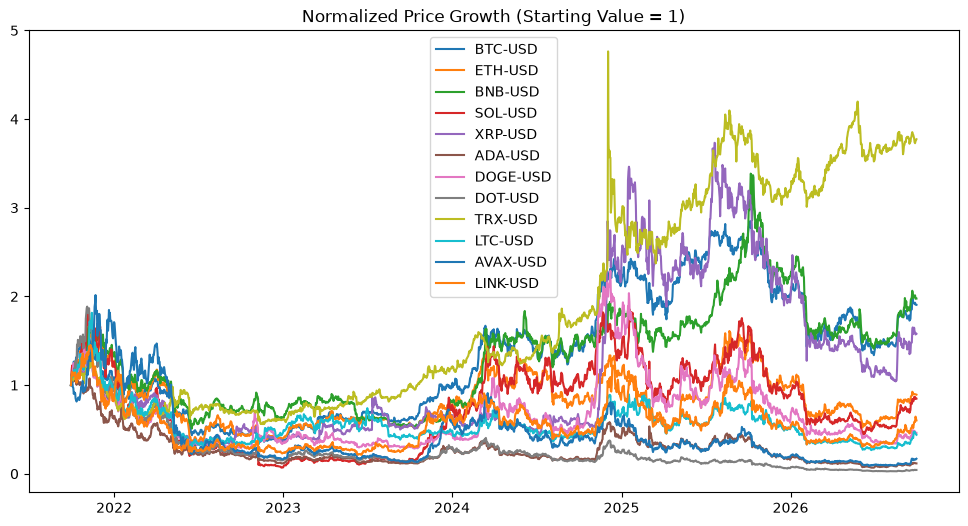

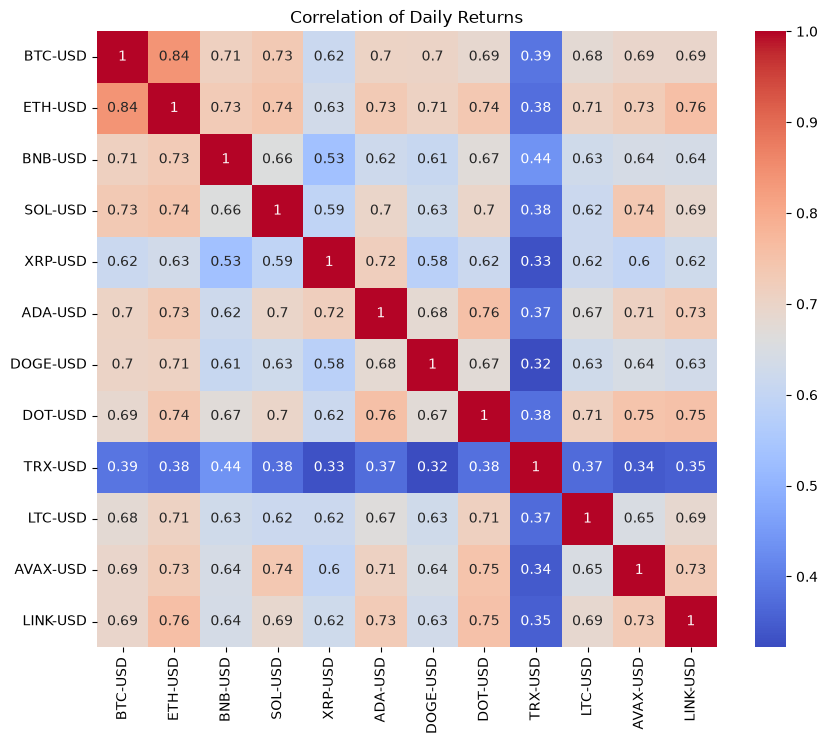

AVAX-USD    0.938007
SOL-USD     0.934419
DOGE-USD    0.899183
ADA-USD     0.875133
LINK-USD    0.865304
XRP-USD     0.834612
DOT-USD     0.834026
LTC-USD     0.744763
ETH-USD     0.688680
TRX-USD     0.643514
BNB-USD     0.569531
BTC-USD     0.514528
dtype: float64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize prices to compare trends on one chart (since BTC ~$60k, DOGE ~$0.10)
plt.figure(figsize=(12,6))
for c in coins_12:
    normalized = data[c]['Close'] / data[c]['Close'].iloc[0]
    plt.plot(normalized, label=c)
plt.legend()
plt.title('Normalized Price Growth (Starting Value = 1)')
plt.show()

# Daily returns + correlation heatmap
returns = pd.DataFrame({c: data[c]['Close'].pct_change() for c in coins_12}).dropna()
plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Daily Returns')
plt.show()

# Volatility comparison
volatility = returns.std() * (365 ** 0.5)  # annualized
print(volatility.sort_values(ascending=False))

In [24]:
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

def add_indicators(df):
    df = df.copy()
    df['SMA_20'] = SMAIndicator(df['Close'], window=20).sma_indicator()
    df['EMA_20'] = EMAIndicator(df['Close'], window=20).ema_indicator()
    df['RSI'] = RSIIndicator(df['Close'], window=14).rsi()
    macd = MACD(df['Close'])
    df['MACD'] = macd.macd()
    bb = BollingerBands(df['Close'], window=20)
    df['BB_upper'] = bb.bollinger_hband()
    df['BB_lower'] = bb.bollinger_lband()
    df.dropna(inplace=True)
    return df

for c in list(data.keys()):
    data[c] = add_indicators(data[c])

In [40]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

features = ['Close','SMA_20','EMA_20','RSI','MACD','BB_upper','BB_lower']
window = 60

def create_sequences(df, features, window=60):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features])
    
    returns = df['Close'].pct_change().fillna(0).values  # daily % return, e.g. 0.02 = +2%
    
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i-window:i])   # input: past 60 days of scaled features
        y.append(returns[i])           # target: next day's actual % return
    return np.array(X), np.array(y), scaler

In [41]:
X_all, y_all = [], []
for c in coins_12:
    X_c, y_c, _ = create_sequences(data[c], features, window)
    X_all.append(X_c)
    y_all.append(y_c)

X_all = np.concatenate(X_all)
y_all = np.concatenate(y_all)

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, shuffle=False)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1)

Epoch 1/30


/opt/anaconda3/envs/crypto_lstm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


471/471 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0060 - val_loss: 0.0011
Epoch 2/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 3/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0018 - val_loss: 0.0013
Epoch 4/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 5/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 6/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 7/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 8/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 9/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 10/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 11/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 12/30
471/471 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/ste

In [42]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = model.predict(X_test)

actual_direction = np.sign(np.diff(y_test))
pred_direction = np.sign(np.diff(preds.flatten()))
directional_accuracy = np.mean(actual_direction == pred_direction)
print(f"Directional Accuracy: {directional_accuracy:.2%}")

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"RMSE: {rmse:.4f}")

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Directional Accuracy: 34.01%
RMSE: 0.0453


In [36]:
for c in coins_12:
    X_c, y_c, scaler_c = create_sequences(data[c], features, window)
    last_sequence = X_c[-1].reshape(1, window, len(features))
    pred_scaled = model.predict(last_sequence, verbose=0)[0][0]
    print(f"{c}: raw scaled prediction = {pred_scaled:.3f}")

BTC-USD: raw scaled prediction = 0.496
ETH-USD: raw scaled prediction = 0.427
BNB-USD: raw scaled prediction = 0.452
SOL-USD: raw scaled prediction = 0.427
XRP-USD: raw scaled prediction = 0.383
ADA-USD: raw scaled prediction = 0.104
DOGE-USD: raw scaled prediction = 0.136
DOT-USD: raw scaled prediction = 0.097
TRX-USD: raw scaled prediction = 0.792
LTC-USD: raw scaled prediction = 0.175
AVAX-USD: raw scaled prediction = 0.102
LINK-USD: raw scaled prediction = 0.294


In [43]:
predicted_returns = {}
for c in coins_12:
    X_c, y_c, scaler_c = create_sequences(data[c], features, window)
    last_sequence = X_c[-1].reshape(1, window, len(features))
    predicted_return = model.predict(last_sequence, verbose=0)[0][0]
    predicted_returns[c] = predicted_return

predicted_returns_series = pd.Series(predicted_returns)
print(predicted_returns_series.sort_values(ascending=False))

DOT-USD    -0.001376
AVAX-USD   -0.001385
ADA-USD    -0.001402
LTC-USD    -0.001421
DOGE-USD   -0.001503
LINK-USD   -0.001645
XRP-USD    -0.001880
SOL-USD    -0.001918
ETH-USD    -0.001932
BNB-USD    -0.002167
BTC-USD    -0.002283
TRX-USD    -0.002837
dtype: float32


In [46]:
returns = pd.DataFrame({c: data[c]['Close'].pct_change() for c in coins_12}).dropna()
cov_matrix = returns[coins_12].cov()
n = len(coins_12)
target_return = predicted_returns_series.mean()

def portfolio_variance(w, cov_matrix):
    return w.T @ cov_matrix @ w

constraints = (
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'eq', 'fun': lambda w: w @ predicted_returns_series.values - target_return}
)
bounds = [(0, 1) for _ in range(n)]
init_guess = np.array([1/n] * n)

result = minimize(portfolio_variance, init_guess, args=(cov_matrix,),
                   method='SLSQP', bounds=bounds, constraints=constraints)

print("Success:", result.success)
print("Message:", result.message)
print("Final objective (variance):", result.fun)

weights = pd.Series(result.x, index=coins_12)
print(weights.sort_values(ascending=False))

Success: True
Message: Optimization terminated successfully
Final objective (variance): 0.0011096753285956855
BTC-USD     0.083333
ETH-USD     0.083333
BNB-USD     0.083333
SOL-USD     0.083333
XRP-USD     0.083333
ADA-USD     0.083333
DOGE-USD    0.083333
DOT-USD     0.083333
TRX-USD     0.083333
LTC-USD     0.083333
AVAX-USD    0.083333
LINK-USD    0.083333
dtype: float64


<Axes: title={'center': 'Cumulative Returns: Optimized vs Equal Weight'}, xlabel='Date'>

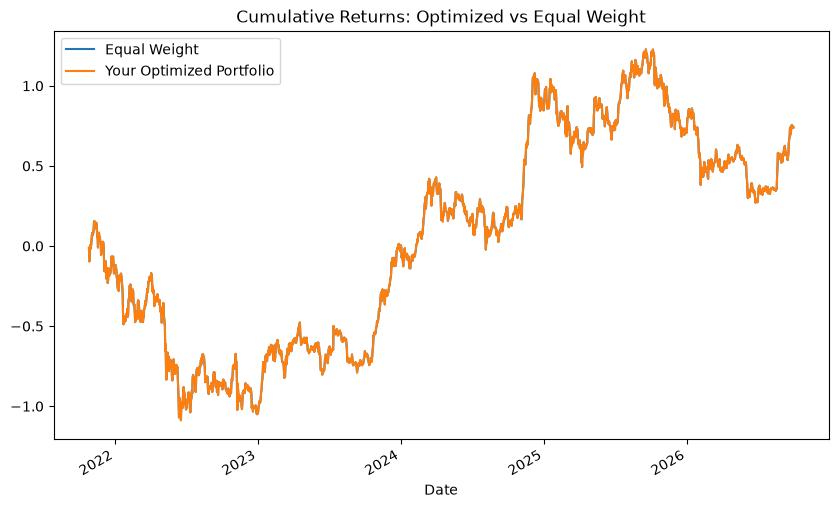

In [45]:
# 1. Generate predicted returns (the code you just pasted)
equal_weight_return = returns[coins_12].mean(axis=1)
your_portfolio_return = (returns[coins_12] * weights.values).sum(axis=1)

comparison = pd.DataFrame({
    'Equal Weight': equal_weight_return.cumsum(),
    'Your Optimized Portfolio': your_portfolio_return.cumsum()
})
comparison.plot(figsize=(10,6), title='Cumulative Returns: Optimized vs Equal Weight')

In [47]:
target_return = predicted_returns_series.max()  # instead of .mean()

constraints = (
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
    {'type': 'eq', 'fun': lambda w: w @ predicted_returns_series.values - target_return}
)

result2 = minimize(portfolio_variance, init_guess, args=(cov_matrix,),
                    method='SLSQP', bounds=bounds, constraints=constraints)

print("Success:", result2.success)
weights2 = pd.Series(result2.x, index=coins_12)
print(weights2.sort_values(ascending=False))

Success: True
DOT-USD     1.000000e+00
TRX-USD     3.444467e-14
LINK-USD    2.112199e-14
DOGE-USD    9.298118e-15
ADA-USD     3.969047e-15
LTC-USD     3.469447e-15
XRP-USD     1.068590e-15
BTC-USD     0.000000e+00
ETH-USD     0.000000e+00
BNB-USD     0.000000e+00
SOL-USD     0.000000e+00
AVAX-USD    0.000000e+00
dtype: float64
